In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 -4*x+5

In [4]:
f(3.0)

20.0

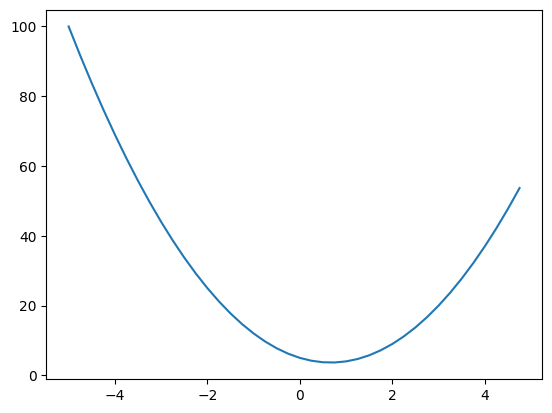

In [5]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)


In [6]:
h=0.001
x=3.0
(f(x+h)-f(x))/h

14.00300000000243

In [7]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [8]:
h=0.0001
d1=a*b+c
a+=h
d2=a*b+c
print(d1)
print(d2)
# dh/dc
print('slope',(d2-d1)/h)

4.0
3.999699999999999
slope -3.000000000010772


In [9]:
class Value:
    def __init__(self,data,_children=(),_op="",label=''):
        self.data=data
        self.grad=0.0
        self._prev=set(_children)
        self._op=_op
        self.label=label
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),_op='+')
        return out
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),_op='*')
        return out
    def __sub__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data-other.data,_op='-')
        return out
    def __truediv__(self, other):
        other=other if isinstance(other,Value) else Value(other)
        out = Value(self.data / other.data, (self, other), _op='/')
        return out
a=Value(2.0)
b=Value(-3.0)
c=Value(5.0)
d=a*b+c
d

Value(data=-1.0)

In [10]:
d._prev # 哪两个数字算出的d

{Value(data=-6.0), Value(data=5.0)}

In [11]:
d._op # 什么操作算出的d

'+'

In [ ]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from graphviz import Digraph

def trace(root):
    nodes,edges=set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot=Digraph(format='svg',graph_attr={'rankdir':'LR'})
    nodes,edges=trace(root)
    for n in nodes:
        uid=str(id(n))

        dot.node(name=uid,label="{ %s|data %.4f|grad%.4f}"%(n.label,n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)
    
    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot 

0.0


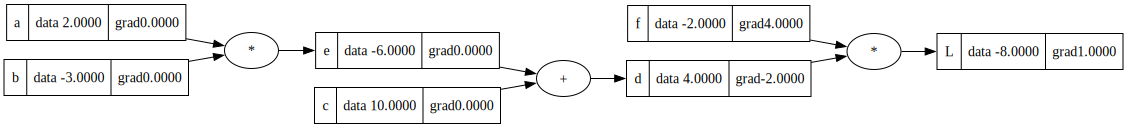

In [19]:
def lol():
    h=0.0001
    # calculate the derivative of L
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e=a*b; e.label='e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'
    L1=L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e=a*b; e.label='e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'
    L2=L.data

    # grad
    f.grad=4
    d.grad=-2
    L.grad=1


    
    
    print((L2-L1)/h)
    return L
L=lol()
draw_dot(L)

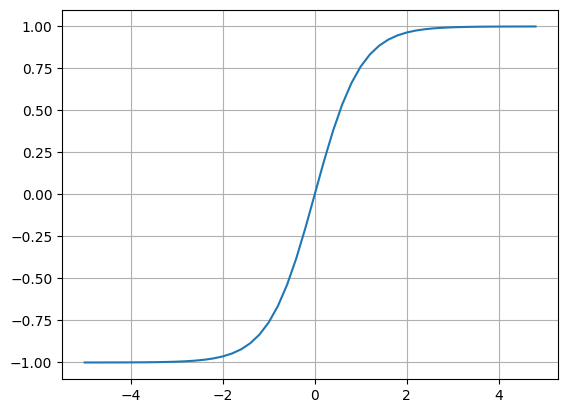

In [23]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid();
